In [1]:
import pandas as pd
import io
import re

def extract_info_field(info_str, field):
    """Hàm hỗ trợ dùng regex để trích xuất giá trị từ cột INFO"""
    match = re.search(r'\b' + field + r'=([^;]+)', str(info_str))
    return match.group(1) if match else None

def extract_gene_symbol(info_str):
    """Hàm trích xuất riêng tên Gen từ chuỗi GENEINFO=GeneSymbol:ID"""
    match = re.search(r'\bGENEINFO=([^;]+)', str(info_str))
    if match:
        # Lấy phần tử đầu tiên trước dấu hai chấm (:) để lấy tên gen gốc
        return match.group(1).split(':')[0] 
    return "Unknown"

def create_clinvar_hq(vcf_path, output_path):
    print("1. Đang nạp dữ liệu VCF (bỏ qua siêu dữ liệu)...")
    # Thêm encoding='utf-8' để đảm bảo không bị lỗi ký tự khi đọc file lớn
    with open(vcf_path, 'r', encoding='utf-8') as f:
        lines = [l for l in f if not l.startswith('##')]
    
    # Sử dụng Pandas để đọc dạng bảng
    df = pd.read_csv(io.StringIO(''.join(lines)), sep='\t', dtype={'#CHROM': str})
    
    print("2. Đang bóc tách các đặc trưng từ cột INFO...")
    df['CLNREVSTAT'] = df['INFO'].apply(lambda x: extract_info_field(x, 'CLNREVSTAT'))
    df['CLNSIG'] = df['INFO'].apply(lambda x: extract_info_field(x, 'CLNSIG'))
    df['MC'] = df['INFO'].apply(lambda x: extract_info_field(x, 'MC'))
    
    # Bổ sung: Bóc tách thêm trường GeneInfo
    df['GeneInfo'] = df['INFO'].apply(extract_gene_symbol)
    
    print("3. Đang áp dụng các bộ lọc chuẩn High-Quality...")
    # Điều kiện 1: Phải là đột biến sai nghĩa (Missense)
    cond_missense = df['MC'].str.contains('missense_variant', na=False)
    
    # Điều kiện 2: Chỉ lấy mức độ đánh giá cao (2, 3, 4 sao)
    hq_statuses = [
        'practice_guideline',                                   # 4 sao
        'reviewed_by_expert_panel',                             # 3 sao
        'criteria_provided,_multiple_submitters,_no_conflicts'  # 2 sao (Có thể bỏ nếu muốn gắt gao hơn)
    ]
    cond_review = df['CLNREVSTAT'].isin(hq_statuses)
    
    # Điều kiện 3: Loại bỏ các nhãn VUS, mâu thuẫn; chỉ giữ Pathogenic/Benign
    valid_sigs = ['Pathogenic', 'Likely_pathogenic', 'Benign', 'Likely_benign']
    cond_sig = df['CLNSIG'].isin(valid_sigs)
    
    # Áp dụng đồng thời 3 lớp lọc
    df_hq = df[cond_missense & cond_review & cond_sig].copy()
    
    print("4. Đang gán nhãn nhị phân cho mô hình học sâu...")
    # Binary Label: 1 = Gây bệnh, 0 = Lành tính
    df_hq['Label'] = df_hq['CLNSIG'].apply(
        lambda x: 1 if x in ['Pathogenic', 'Likely_pathogenic'] else 0
    )
    
    # Bổ sung 'GeneInfo' vào danh sách các cột được giữ lại
    columns_to_keep = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'GeneInfo', 'CLNSIG', 'CLNREVSTAT', 'Label']
    df_final = df_hq[columns_to_keep]
    
    # Lưu ra file. Lưu ý: sep='\t' (Tab) nhưng đuôi là .csv, 
    # Excel vẫn mở bình thường nếu chọn chế độ delimiter là Tab.
    df_final.to_csv(output_path, index=False, sep='\t')
    
    print(f"Hoàn tất! Đã trích xuất được {len(df_final)} biến thể đạt chuẩn HQ.")
    print(f"Dữ liệu được lưu tại: {output_path}")
    
    return df_final

# Thực thi đoạn code trên máy trạm
hq_dataset = create_clinvar_hq(r'D:\Study\AiTa_Lab_Research\clinvar.vcf', r'D:\Study\AiTa_Lab_Research\clinvar_hq_filtered.csv')

1. Đang nạp dữ liệu VCF (bỏ qua siêu dữ liệu)...
2. Đang bóc tách các đặc trưng từ cột INFO...
3. Đang áp dụng các bộ lọc chuẩn High-Quality...
4. Đang gán nhãn nhị phân cho mô hình học sâu...
Hoàn tất! Đã trích xuất được 38487 biến thể đạt chuẩn HQ.
Dữ liệu được lưu tại: D:\Study\AiTa_Lab_Research\clinvar_hq_filtered.csv


In [3]:
import pandas as pd
import io
import re

def extract_info_field(info_str, field):
    match = re.search(r'\b' + field + r'=([^;]+)', str(info_str))
    return match.group(1) if match else None

def verify_clinvar_filtering(vcf_path):
    print("1. Đang nạp dữ liệu VCF...")
    with open(vcf_path, 'r') as f:
        lines = [l for l in f if not l.startswith('##')]
    
    df = pd.read_csv(io.StringIO(''.join(lines)), sep='\t', dtype={'#CHROM': str})
    total_initial = len(df)
    print(f"-> TỔNG SỐ DÒNG BAN ĐẦU: {total_initial:,}")
    
    print("\n2. Đang bóc tách cột INFO...")
    df['CLNREVSTAT'] = df['INFO'].apply(lambda x: extract_info_field(x, 'CLNREVSTAT'))
    df['CLNSIG'] = df['INFO'].apply(lambda x: extract_info_field(x, 'CLNSIG'))
    df['MC'] = df['INFO'].apply(lambda x: extract_info_field(x, 'MC'))
    
    # --- BỘ LỌC 1: Chỉ lấy Missense ---
    cond_missense = df['MC'].str.contains('missense_variant', na=False)
    df_missense = df[cond_missense]
    print(f"\n-> BỘ LỌC 1 (Chỉ giữ Missense): Còn lại {len(df_missense):,} dòng")
    print(f"   Đã loại bỏ {total_initial - len(df_missense):,} dòng (Các loại đột biến khác)")

    # --- BỘ LỌC 2: Loại bỏ VUS, chỉ lấy Pathogenic/Benign ---
    valid_sigs = ['Pathogenic', 'Likely_pathogenic', 'Benign', 'Likely_benign']
    cond_sig = df_missense['CLNSIG'].isin(valid_sigs)
    df_sig = df_missense[cond_sig]
    print(f"\n-> BỘ LỌC 2 (Có nhãn rõ ràng): Còn lại {len(df_sig):,} dòng")
    print(f"   Đã loại bỏ {len(df_missense) - len(df_sig):,} dòng (Chủ yếu là VUS)")

    # --- BỘ LỌC 3: Mức độ tin cậy cao (High-Quality) ---
    hq_statuses = [
        'practice_guideline', 
        'reviewed_by_expert_panel', 
        'criteria_provided,_multiple_submitters,_no_conflicts'
    ]
    cond_review = df_sig['CLNREVSTAT'].isin(hq_statuses)
    df_hq = df_sig[cond_review]
    print(f"\n-> BỘ LỌC 3 (Đạt chuẩn 2-4 sao): Còn lại {len(df_hq):,} dòng")
    print(f"   Đã loại bỏ {len(df_sig) - len(df_hq):,} dòng (Các biến thể 0-1 sao)")
    
    print("\n======================================")
    print(f"TỔNG KẾT TẬP CLINVAR_HQ: {len(df_hq):,} đột biến")
    print("======================================")
    
    return df_hq

# Chạy kiểm tra
df_check = verify_clinvar_filtering('clinvar.vcf')

1. Đang nạp dữ liệu VCF...
-> TỔNG SỐ DÒNG BAN ĐẦU: 4,461,470

2. Đang bóc tách cột INFO...

-> BỘ LỌC 1 (Chỉ giữ Missense): Còn lại 2,532,534 dòng
   Đã loại bỏ 1,928,936 dòng (Các loại đột biến khác)

-> BỘ LỌC 2 (Có nhãn rõ ràng): Còn lại 197,853 dòng
   Đã loại bỏ 2,334,681 dòng (Chủ yếu là VUS)

-> BỘ LỌC 3 (Đạt chuẩn 2-4 sao): Còn lại 38,487 dòng
   Đã loại bỏ 159,366 dòng (Các biến thể 0-1 sao)

TỔNG KẾT TẬP CLINVAR_HQ: 38,487 đột biến


1. DATASET OVERVIEW
├── Shape (Số dòng, Số cột): (38487, 9)
├── Columns: ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'GeneInfo', 'CLNSIG', 'CLNREVSTAT', 'Label']
├── Data types:
#CHROM        object
POS            int64
ID             int64
REF           object
ALT           object
GeneInfo      object
CLNSIG        object
CLNREVSTAT    object
Label          int64
dtype: object
└── Unique values per column:
#CHROM           24
POS           37430
ID            38487
REF              38
ALT              37
GeneInfo       6894
CLNSIG            4
CLNREVSTAT        3
Label             2
dtype: int64

2. DATA QUALITY
├── Missing values:
#CHROM        0
POS           0
ID            0
REF           0
ALT           0
GeneInfo      0
CLNSIG        0
CLNREVSTAT    0
Label         0
dtype: int64
├── Duplicates: 0
├── Invalid/Unusual Chromosomes: []
└── Inconsistent categories (CLNSIG):
CLNSIG
Benign               15717
Likely_benign        10357
Pathogenic            6245
Likely_pathogenic     6168
N

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34008\4201441218.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='#CHROM', order=[c for c in chrom_order if c in df['#CHROM'].unique()], ax=axes[0], palette='viridis')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34008\4201441218.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34008\4201441218.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Benign (0)', 'Pathogenic (1)'])


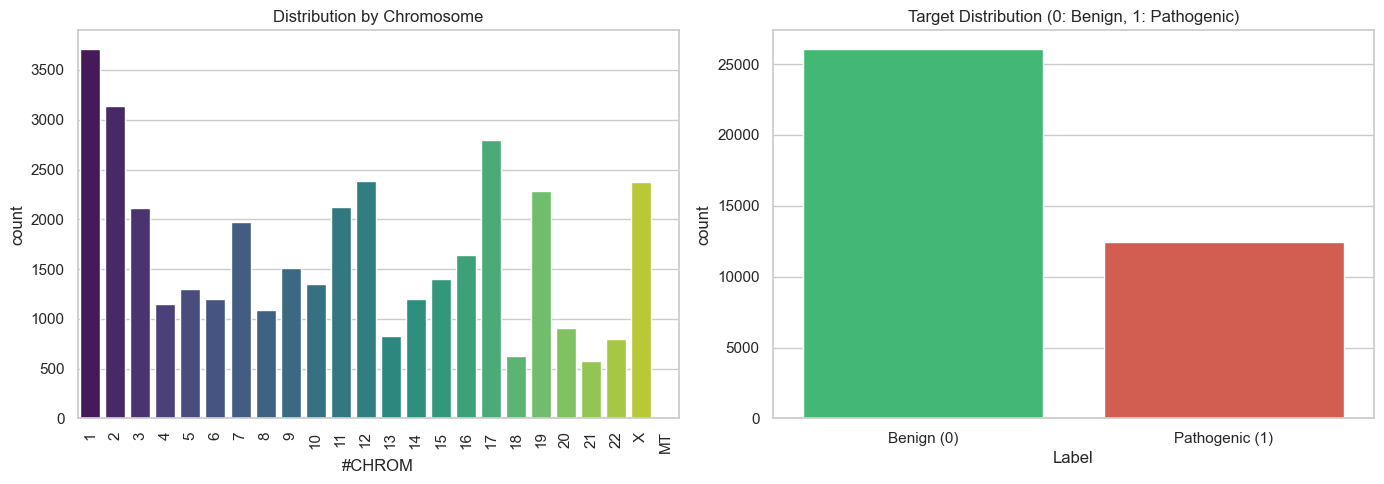


4. BIVARIATE ANALYSIS


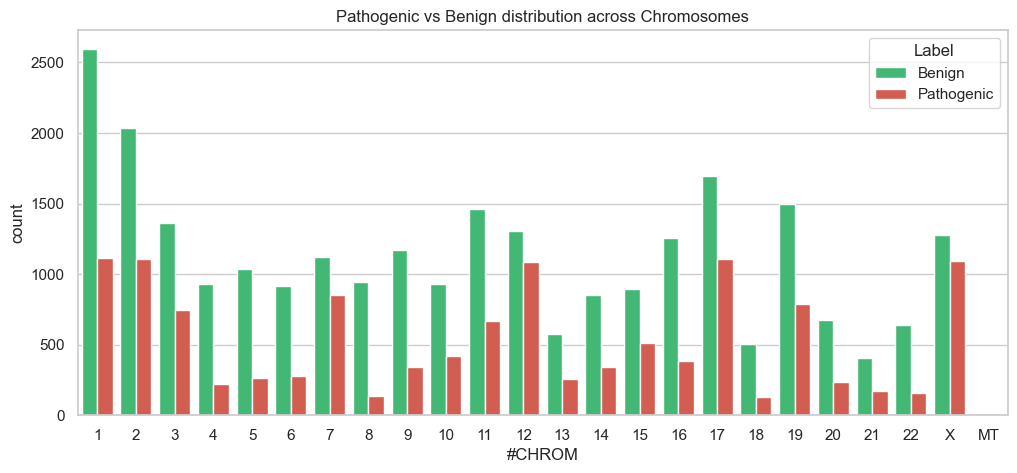


5. GENE-LEVEL ANALYSIS (Phân tích theo Gen)
├── TOP 10 GEN CÓ NHIỀU BIẾN THỂ NHẤT:
GeneInfo  Total_Variants  Pathogenic_Count  Benign_Count  Pathogenic_Rate (%)
     PAH             398               396             2                99.50
   BRCA1             299               116           183                38.80
    LDLR             297               286            11                96.30
     GCK             294               285             9                96.94
    FBN1             264               251            13                95.08
   BRCA2             255                62           193                24.31
    TP53             166                88            78                53.01
   HNF1A             152               122            30                80.26
     GAA             150               138            12                92.00
   MECP2             149                50            99                33.56

├── THỐNG KÊ TỔNG QUAN:
    - Tổng số gen duy nhất trong 

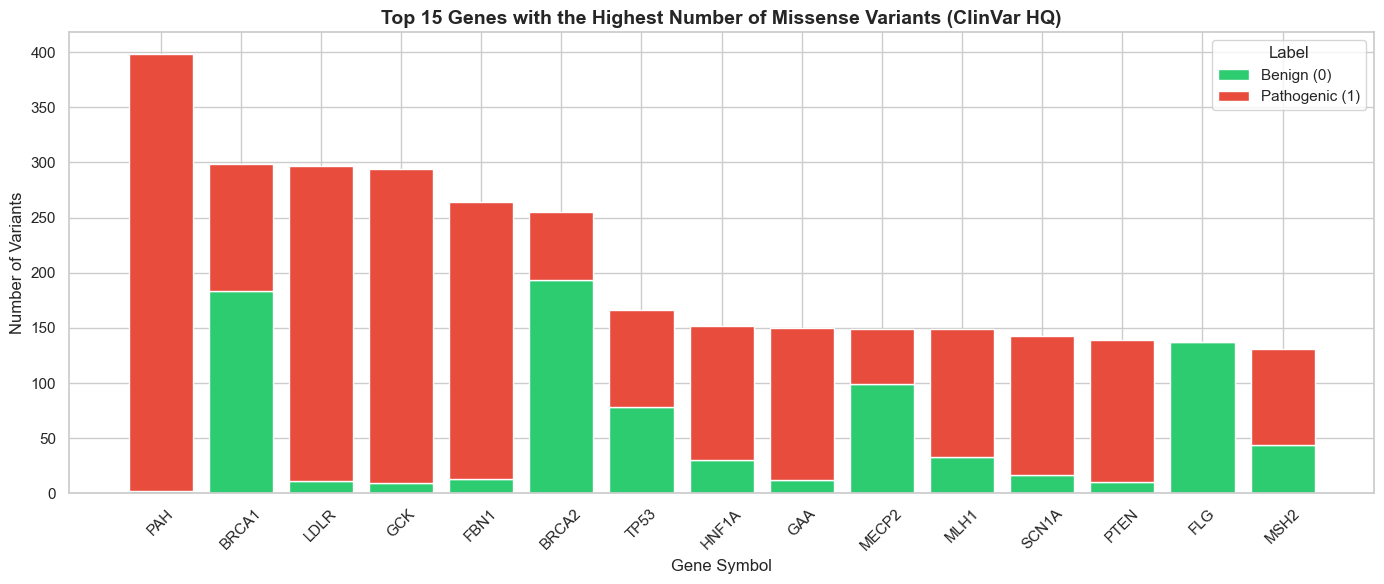

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình hiển thị đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu
df = pd.read_csv(r'D:\Study\AiTa_Lab_Research\clinvar_hq_filtered.csv', sep='\t', dtype={'#CHROM': str})

print("="*50)
print("1. DATASET OVERVIEW")
print("="*50)
print(f"├── Shape (Số dòng, Số cột): {df.shape}")
print(f"├── Columns: {list(df.columns)}")
print("├── Data types:")
print(df.dtypes)
print("└── Unique values per column:")
print(df.nunique())

print("\n" + "="*50)
print("2. DATA QUALITY")
print("="*50)
print("├── Missing values:")
print(df.isnull().sum())
print(f"├── Duplicates: {df.duplicated().sum()}")
# Kiểm tra invalid values: Chromosome có nằm ngoài 1-22, X, Y, MT không?
valid_chroms = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
invalid_chroms = df[~df['#CHROM'].isin(valid_chroms)]['#CHROM'].unique()
print(f"├── Invalid/Unusual Chromosomes: {invalid_chroms}")
print("└── Inconsistent categories (CLNSIG):")
print(df['CLNSIG'].value_counts())

print("\n" + "="*50)
print("3. UNIVARIATE ANALYSIS (Trực quan hóa)")
print("="*50)
# Chỉnh lại thành 1 dòng, 2 cột để không bị thừa đồ thị trống
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Categorical distribution (Chromosome)
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
sns.countplot(data=df, x='#CHROM', order=[c for c in chrom_order if c in df['#CHROM'].unique()], ax=axes[0], palette='viridis')
axes[0].set_title('Distribution by Chromosome')
axes[0].tick_params(axis='x', rotation=90)

# Target distribution (Label)
sns.countplot(data=df, x='Label', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Target Distribution (0: Benign, 1: Pathogenic)')
axes[1].set_xticklabels(['Benign (0)', 'Pathogenic (1)'])
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("4. BIVARIATE ANALYSIS")
print("="*50)
# Categorical <-> Categorical (Chromosome vs Label)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='#CHROM', hue='Label', order=[c for c in chrom_order if c in df['#CHROM'].unique()], palette=['#2ecc71', '#e74c3c'])
plt.title('Pathogenic vs Benign distribution across Chromosomes')
plt.legend(title='Label', labels=['Benign', 'Pathogenic'])
plt.show()

print("\n" + "="*50)
print("5. GENE-LEVEL ANALYSIS (Phân tích theo Gen)")
print("="*50)

# Kiểm tra đảm bảo cột GeneInfo tồn tại trước khi phân tích
if 'GeneInfo' in df.columns:
    # Nhóm dữ liệu theo Gen và đếm số lượng
    gene_stats = df.groupby('GeneInfo')['Label'].agg(
        Total_Variants='count',
        Pathogenic_Count=lambda x: (x == 1).sum(),
        Benign_Count=lambda x: (x == 0).sum()
    ).reset_index()

    # Sắp xếp theo tổng số biến thể giảm dần
    gene_stats = gene_stats.sort_values('Total_Variants', ascending=False)

    # Tính tỷ lệ % Gây bệnh cho mỗi gen
    gene_stats['Pathogenic_Rate (%)'] = round((gene_stats['Pathogenic_Count'] / gene_stats['Total_Variants']) * 100, 2)

    print("├── TOP 10 GEN CÓ NHIỀU BIẾN THỂ NHẤT:")
    print(gene_stats.head(10).to_string(index=False))

    print("\n├── THỐNG KÊ TỔNG QUAN:")
    print(f"    - Tổng số gen duy nhất trong tập dữ liệu: {gene_stats.shape[0]:,}")
    print(f"    - Trung bình mỗi gen có: {gene_stats['Total_Variants'].mean():.1f} biến thể")
    print(f"    - Gen có nhiều biến thể nhất: {gene_stats.iloc[0]['GeneInfo']} ({gene_stats.iloc[0]['Total_Variants']} biến thể)")
    
    # --- DÒNG CODE ĐƯỢC THÊM MỚI ---
    print(f"    - Trung bình tỷ lệ Gây bệnh (Pathogenic) trên tất cả các gen: {gene_stats['Pathogenic_Rate (%)'].mean():.2f}%")
    # -------------------------------

    # Trực quan hóa: Biểu đồ cột xếp chồng cho Top 15 Gen
    top_15_genes = gene_stats.head(15)

    plt.figure(figsize=(14, 6))
    plt.bar(top_15_genes['GeneInfo'], top_15_genes['Benign_Count'], label='Benign (0)', color='#2ecc71')
    plt.bar(top_15_genes['GeneInfo'], top_15_genes['Pathogenic_Count'], bottom=top_15_genes['Benign_Count'], label='Pathogenic (1)', color='#e74c3c')

    plt.title('Top 15 Genes with the Highest Number of Missense Variants (ClinVar HQ)', fontsize=14, fontweight='bold')
    plt.xlabel('Gene Symbol', fontsize=12)
    plt.ylabel('Number of Variants', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()
else:
    print("Lỗi: Cột 'GeneInfo' không tồn tại. Vui lòng kiểm tra lại file dữ liệu gốc.")